## Chi Square test on Real Dataset — Titanic (Kaggle)

**Dataset:** titanic.csv
**Download from:** https://www.kaggle.com/c/titanic/data

**Question:**
Is survival dependent on Gender?

**H0:** Survival and Gender are INDEPENDENT
**H1:** Survival and Gender are DEPENDENT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [5]:
df = pd.read_csv('/content/train[1].csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
contingency_table = pd.crosstab(df['Sex'], df['Survived'])
contingency_table

Survived,0,1
Sex,,
female,81,233
male,468,109


In [11]:
chi2 , p, dof, expected = chi2_contingency(contingency_table)

print('Chi-square statistic:', chi2)
print('\np-value:', p)
print('\nDegrees of freedom:', dof)
print('\nExpected frequencies table:', expected)

if p < 0.05:
    print('\nReject the null hypothesis')
else:
    print('\nFail to reject the null hypothesis')

survival_rate = df.groupby('Sex')['Survived'].mean() * 100

print("\nsurvival rate by gender")
print(survival_rate)

Chi-square statistic: 260.71702016732104

p-value: 1.1973570627755645e-58

Degrees of freedom: 1

Expected frequencies table: [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]

Reject the null hypothesis

survival rate by gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


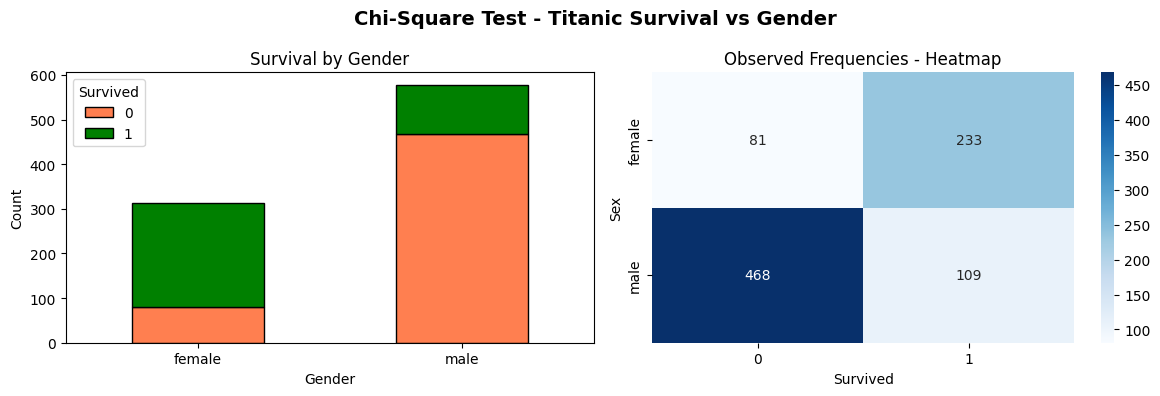

In [14]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contingency_table.plot(kind="bar", stacked=True,
                          color=["coral", "green"],
                          edgecolor="black", ax=axes[0])
axes[0].set_title("Survival by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Survived")

sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Observed Frequencies - Heatmap")

plt.suptitle("Chi-Square Test - Titanic Survival vs Gender", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()